# 1. Imports


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import tensorflow as tf
#from tensorflow import keras
import os
import cv2
import random

# 2. Setting Up the Dataset Path

In [ ]:
print(os.getcwd())
BASE_DIR = os.getcwd()
DATADIR = os.path.join(BASE_DIR, "dataset")


c:\Users\Somaya Ahmad\Desktop\Kidney_stone_detection-


 # 3. Preview One Image Per Category

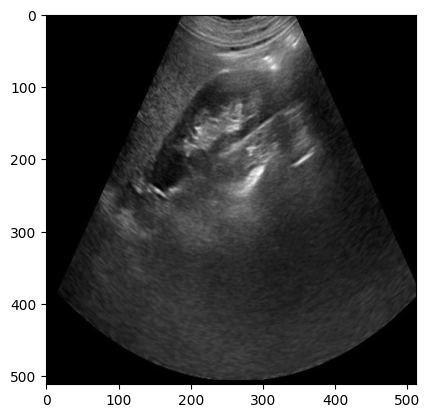

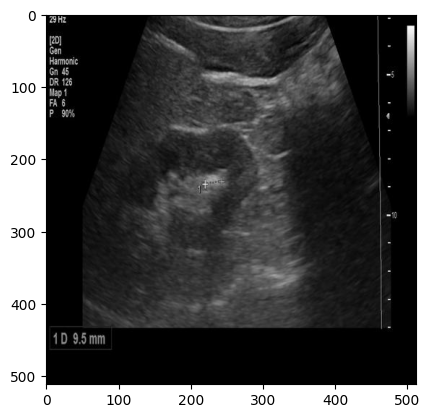

In [38]:

CATEGORIES = ["Normal", "stone"]  # Normal=0, stone=1
for category in CATEGORIES:
    path = os.path.join(DATADIR, category)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array, cmap="gray")
        plt.show()
        break

# 4. Resize the Image

Original Image shape: (512, 512)
Resized Image shape: (225, 225)


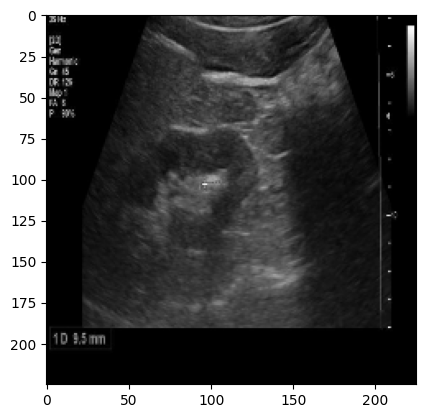

In [39]:
print("Original Image shape:", img_array.shape)  # original size
IMG_SIZE = 225
new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap="gray")
print("Resized Image shape:", new_array.shape)  # resized image
plt.show()

# 5. Build the Training Dataset

In [40]:
training_data = []
def create_training_data():
    for category in CATEGORIES:
        path = os.path.join(DATADIR, category)
        class_num = CATEGORIES.index(category) # stone=0, Normal=1
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                training_data.append([new_array, class_num])
            except Exception as e:
                print(f"Error processing image {img}: {e}")

create_training_data()
print(len(training_data))  # total number of images loaded

2000


#  6. Shuffle & Separate Features/Labels

In [42]:
random.shuffle(training_data)   # prevents the model from learning order

X = []  # features (images)
y = []  # labels (0 or 1)

for feature, label in training_data:
    X.append(feature)
    y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y)

# 7. Save with Pickle
##### Pickle saves Python objects to disk so you don't re-process images every time

In [44]:
import pickle

# Save X (images)
pickle_out = open("X.pickle", "wb")   # "wb" = write binary
pickle.dump(X, pickle_out)
pickle_out.close()

# Save y (labels)
pickle_out = open("y.pickle", "wb")
pickle.dump(y, pickle_out)
pickle_out.close()

# 8. Load Pickle Back

In [45]:
pickle_in = open("X.pickle", "rb")   # "rb" = read binary
X = pickle.load(pickle_in)